# Predicting Student Health Risk — v6: Feature Engineering
### Kaggle Playground Series S6E7

**Recap:**
- v3 LightGBM (tuned): CV 0.94965, leaderboard 0.95011 (current best)
- v4 CatBoost: CV 0.94902
- v5 Ensemble: CV 0.94961 (barely better than LightGBM alone — not worth submitting)

**Why feature engineering now:** the feature importance from v2/v3 shows the 7 numeric
features (`bmi`, `sleep_duration`, `exercise_duration`, `step_count`, `calorie_expenditure`,
`heart_rate`, `water_intake`) completely dominate — all 6 categorical features combined
contribute far less. Since model swaps and ensembling have hit diminishing returns, the next
real lever is giving the model **better-shaped versions of these numeric features**, not a
different algorithm.

**Two kinds of new features added here:**
1. **Ratios/interactions** between the top numeric features (e.g. `step_count / exercise_duration`
   as an activity-intensity measure, `calorie_expenditure / bmi`, etc.)
2. **Missingness features** — this dataset has substantial missing data (e.g. `sleep_duration` is
   only ~89% non-null). In synthetic Playground datasets, *which* values are missing can itself
   carry signal (missing-not-at-random). We add: a per-row count of missing values, and binary
   "was this missing" flags for each numeric column.

Same tuned LightGBM hyperparameters from v3 are reused, so any score change is attributable to
the new features, not a different model config.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/competitions/playground-series-s6e7"


## 1. Load the data

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

target_col = "health_condition"
orig_feature_cols = [c for c in train.columns if c not in [target_col, "id"]]

X = train[orig_feature_cols].copy()
y = train[target_col].copy()
X_test = test[orig_feature_cols].copy()

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 2. Missingness features

Before filling any missing values, capture *where* they were missing — this info gets destroyed
once we impute, so we need to do it first.

In [3]:
def add_missingness_features(df, num_cols, cat_cols):
    df = df.copy()
    all_cols = num_cols + cat_cols
    # Per-row count of missing values across all original features
    df["missing_count"] = df[all_cols].isnull().sum(axis=1)
    # Binary flag for each numeric column (categoricals get a natural "missing" category later anyway)
    for c in num_cols:
        df[f"{c}_was_missing"] = df[c].isnull().astype(int)
    return df

X = add_missingness_features(X, num_cols, cat_cols)
X_test = add_missingness_features(X_test, num_cols, cat_cols)

print("missing_count distribution:")
print(X["missing_count"].value_counts().sort_index())

missing_count distribution:
missing_count
0    349623
1    248134
2     77311
3     13445
4      1479
5        87
6         9
Name: count, dtype: int64


## 3. Impute missing values (same approach as before: median for numeric, "missing" category for categorical)

In [4]:
for c in num_cols:
    med = X[c].median()
    X[c] = X[c].fillna(med)
    X_test[c] = X_test[c].fillna(med)

for c in cat_cols:
    X[c] = X[c].fillna("missing")
    X_test[c] = X_test[c].fillna("missing")

## 4. Ratio / interaction features among the top numeric predictors

These are engineered *after* imputation, using the filled values. Each one is a simple,
interpretable combination — e.g. "activity intensity" (steps per minute of exercise), or
"caloric efficiency" (calories burned per step) — that a raw model can't easily reconstruct
from the individual columns alone via simple tree splits.

In [5]:
def add_interaction_features(df):
    df = df.copy()
    eps = 1e-3  # avoid division by zero

    df["steps_per_exercise_min"] = df["step_count"] / (df["exercise_duration"] + eps)
    df["calories_per_step"] = df["calorie_expenditure"] / (df["step_count"] + eps)
    df["calories_per_exercise_min"] = df["calorie_expenditure"] / (df["exercise_duration"] + eps)
    df["calories_per_bmi"] = df["calorie_expenditure"] / (df["bmi"] + eps)
    df["steps_per_bmi"] = df["step_count"] / (df["bmi"] + eps)
    df["water_per_bmi"] = df["water_intake"] / (df["bmi"] + eps)
    df["sleep_per_bmi"] = df["sleep_duration"] / (df["bmi"] + eps)
    df["heart_rate_x_exercise"] = df["heart_rate"] * df["exercise_duration"]
    df["heart_rate_per_bmi"] = df["heart_rate"] / (df["bmi"] + eps)
    df["sleep_x_water"] = df["sleep_duration"] * df["water_intake"]
    df["activity_score"] = df["step_count"] * df["exercise_duration"] / (df["calorie_expenditure"] + eps)

    return df

X = add_interaction_features(X)
X_test = add_interaction_features(X_test)

new_feature_cols = [c for c in X.columns if c not in orig_feature_cols]
print(f"Added {len(new_feature_cols)} new features:")
print(new_feature_cols)

Added 19 new features:
['missing_count', 'sleep_duration_was_missing', 'heart_rate_was_missing', 'bmi_was_missing', 'calorie_expenditure_was_missing', 'step_count_was_missing', 'exercise_duration_was_missing', 'water_intake_was_missing', 'steps_per_exercise_min', 'calories_per_step', 'calories_per_exercise_min', 'calories_per_bmi', 'steps_per_bmi', 'water_per_bmi', 'sleep_per_bmi', 'heart_rate_x_exercise', 'heart_rate_per_bmi', 'sleep_x_water', 'activity_score']


## 5. Set dtypes and encode target (same as v3)

In [6]:
all_cat_cols = cat_cols  # missingness flags/counts and ratios are numeric, no change needed here
all_num_cols = [c for c in X.columns if c not in all_cat_cols]

for c in all_cat_cols:
    all_cats = pd.concat([X[c], X_test[c]]).astype(str).unique()
    X[c] = X[c].astype(str).astype(pd.CategoricalDtype(categories=all_cats))
    X_test[c] = X_test[c].astype(str).astype(pd.CategoricalDtype(categories=all_cats))

target_encoder = LabelEncoder()
y_enc = target_encoder.fit_transform(y)

feature_cols = list(X.columns)
print(f"Total features now: {len(feature_cols)} (was {len(orig_feature_cols)})")
print(dict(zip(target_encoder.classes_, range(len(target_encoder.classes_)))))

Total features now: 32 (was 13)
{'at-risk': 0, 'fit': 1, 'unhealthy': 2}


## 6. Train and validate with the same tuned LightGBM params from v3

Reusing v3's best hyperparameters (found via Optuna) so this is a clean comparison — the only
thing that changed is the feature set.

In [7]:
# Best params from v3's Optuna search — update these if your v3 run found different values
best_params = {
    'n_estimators': 500,
    'learning_rate': 0.03426069502422001,
    'num_leaves': 23,
    'max_depth': 9,
    'min_child_samples': 18,
    'subsample': 0.7293691429332224,
    'colsample_bytree': 0.5962321115660644,
    'reg_alpha': 5.178964936328794e-07,
    'reg_lambda': 7.656695372261228e-07,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
test_preds_folds = []
oof_proba = np.zeros((len(X), 3))
feature_importances = np.zeros(len(feature_cols))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_enc)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_enc[train_idx], y_enc[val_idx]

    model = LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)]
    )

    val_pred_proba = model.predict_proba(X_val)
    oof_proba[val_idx] = val_pred_proba

    val_pred = np.argmax(val_pred_proba, axis=1)
    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold+1} balanced accuracy: {score:.5f}")

    test_preds_folds.append(model.predict_proba(X_test))
    feature_importances += model.feature_importances_ / skf.n_splits

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print(f"v3 (original features):  0.94965")

Fold 1 balanced accuracy: 0.95040
Fold 2 balanced accuracy: 0.95152
Fold 3 balanced accuracy: 0.94902
Fold 4 balanced accuracy: 0.94941
Fold 5 balanced accuracy: 0.94796

Mean CV balanced accuracy: 0.94966 (+/- 0.00121)
v3 (original features):  0.94965


## 7. Feature importance — did the new features earn their place?

sleep_duration               3523.0
bmi                          2928.0
sleep_per_bmi                2326.4
water_intake                 1976.8
heart_rate                   1678.2
stress_level                 1657.6
calories_per_bmi             1333.2
heart_rate_per_bmi           1315.4
sleep_x_water                1299.6
activity_score               1290.4
calorie_expenditure          1259.0
exercise_duration            1240.4
calories_per_exercise_min    1142.4
water_per_bmi                1107.4
steps_per_exercise_min       1106.0
steps_per_bmi                1080.2
step_count                   1072.8
heart_rate_x_exercise        1043.0
calories_per_step             995.8
physical_activity_level       862.6
dtype: float64


<Axes: title={'center': 'Top 20 Feature Importances (v6)'}>

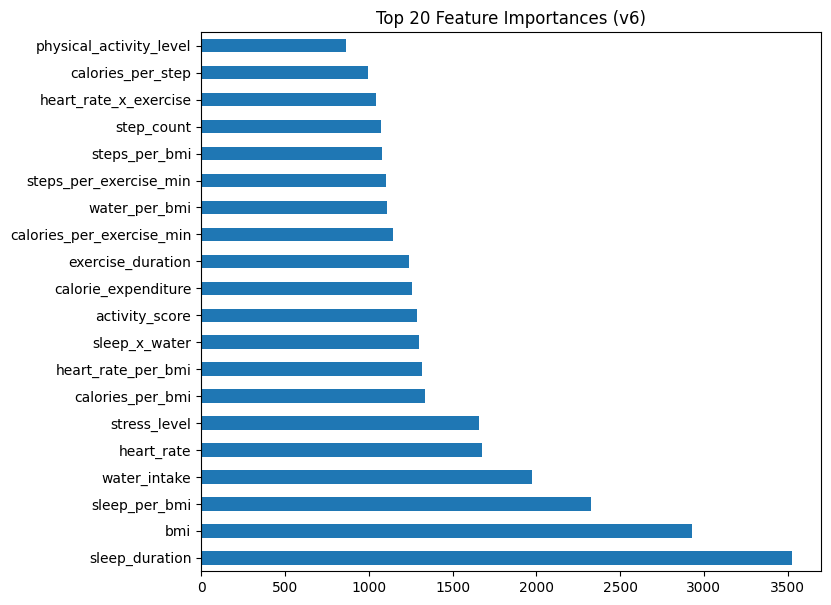

In [8]:
fi = pd.Series(feature_importances, index=feature_cols).sort_values(ascending=False)
print(fi.head(20))
fi.head(20).plot(kind="barh", figsize=(8,7), title="Top 20 Feature Importances (v6)")

## 8. Predict on the test set and save submission

In [9]:
avg_test_proba = np.mean(test_preds_folds, axis=0)
final_preds_enc = np.argmax(avg_test_proba, axis=1)
final_preds = target_encoder.inverse_transform(final_preds_enc)

submission = pd.DataFrame({"id": test["id"], "health_condition": final_preds})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
submission.to_csv("submission.csv", index=False)

np.save("v6_oof_proba.npy", oof_proba)
np.save("v6_test_proba.npy", avg_test_proba)
print(pd.Series(final_preds).value_counts())
submission.head()

at-risk      239534
unhealthy     34368
fit           21851
Name: count, dtype: int64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


## Next steps

1. **Compare** the CV score here against v3's 0.94965.
   - If it's meaningfully higher (e.g. +0.001 or more), submit it — this is a real gain from
     better features, not just noise.
   - If it's about the same or worse, check the feature importance table: if none of the new
     engineered features rank highly, they're not adding information the model couldn't
     already infer from the raw columns — in which case, it's fine to drop this direction and
     try something else (e.g. pseudo-labeling, or different feature combinations).
2. If `missing_count` or the `_was_missing` flags rank highly, that confirms missingness is
   genuinely informative here — worth exploring further (e.g. per-column missing patterns, not
   just a total count).
3. Consider re-running Optuna tuning **on top of this new feature set** — the previously-tuned
   hyperparameters were optimized for the old features, they may not be optimal here.

Keep versioning: this is v6 (feature engineering on tuned LightGBM).